In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/synthetic_nutrition_log.csv")
df.head()

,date,calories,true_weight,weight
0,2026-01-01,2476.0,75.000,75.20
1,2026-01-02,2140.0,75.010,74.98
2,2026-01-03,2588.0,74.976,74.85
3,2026-01-04,2635.0,75.000,74.98
4,2026-01-05,1912.0,75.031,74.52


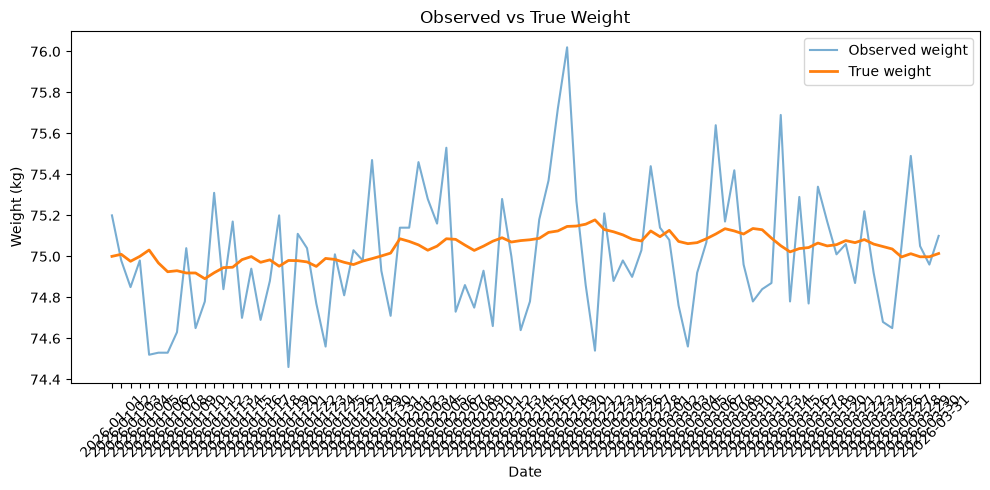

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["weight"], label="Observed weight", alpha=0.6)
plt.plot(df["date"], df["true_weight"], label="True weight", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Weight (kg)")
plt.title("Observed vs True Weight")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
import sys
sys.path.append("..")
from src.smoothing import compute_ema_trend

df_smoothed = compute_ema_trend(df, alpha=0.1)
df_smoothed.head()

,date,calories,true_weight,weight,trend_weight
0,2026-01-01,2476.0,75.000,75.20,75.200
1,2026-01-02,2140.0,75.010,74.98,75.178
2,2026-01-03,2588.0,74.976,74.85,75.145
3,2026-01-04,2635.0,75.000,74.98,75.129
4,2026-01-05,1912.0,75.031,74.52,75.068


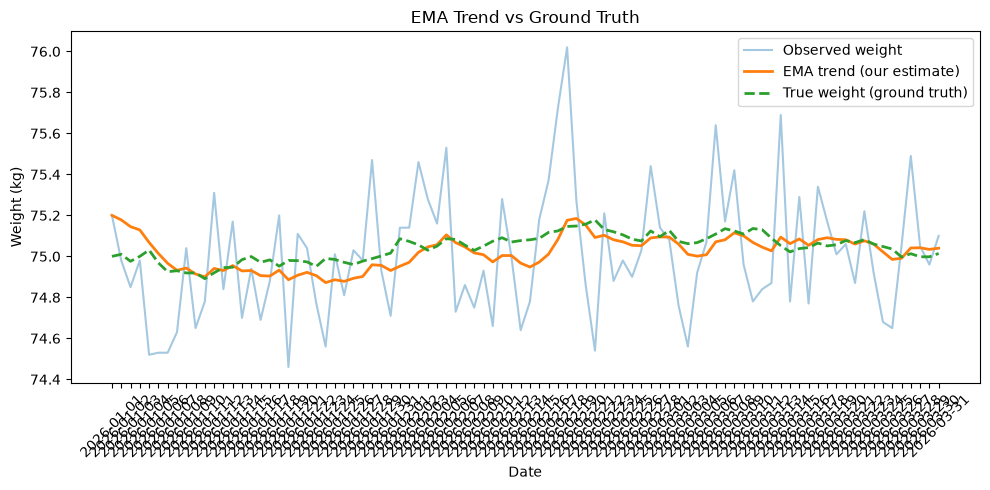

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(df_smoothed["date"], df_smoothed["weight"], label="Observed weight", alpha=0.4)
plt.plot(df_smoothed["date"], df_smoothed["trend_weight"], label="EMA trend (our estimate)", linewidth=2)
plt.plot(df_smoothed["date"], df_smoothed["true_weight"], label="True weight (ground truth)", linewidth=2, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Weight (kg)")
plt.title("EMA Trend vs Ground Truth")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
mae = (df_smoothed["trend_weight"] - df_smoothed["true_weight"]).abs().mean()
print(f"Mean Absolute Error (EMA trend vs true weight): {mae:.4f} kg")

Mean Absolute Error (EMA trend vs true weight): 0.0506 kg


In [6]:
for a in [0.05, 0.1, 0.2, 0.3, 0.5]:
    test = compute_ema_trend(df, alpha=a)
    mae = (test["trend_weight"] - test["true_weight"]).abs().mean()
    print(f"alpha={a}: MAE = {mae:.4f} kg")

alpha=0.05: MAE = 0.0563 kg
alpha=0.1: MAE = 0.0506 kg
alpha=0.2: MAE = 0.0760 kg
alpha=0.3: MAE = 0.1010 kg
alpha=0.5: MAE = 0.1436 kg


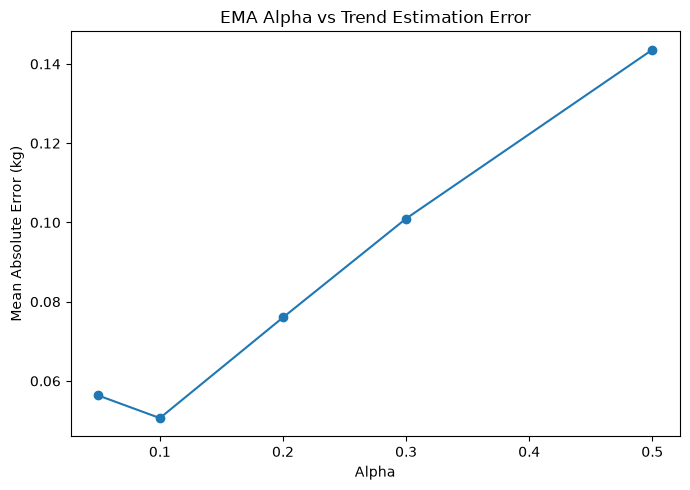

In [7]:
alphas = [0.05, 0.1, 0.2, 0.3, 0.5]
maes = []

for a in alphas:
    test = compute_ema_trend(df, alpha=a)
    mae = (test["trend_weight"] - test["true_weight"]).abs().mean()
    maes.append(mae)

plt.figure(figsize=(7, 5))
plt.plot(alphas, maes, marker="o")
plt.xlabel("Alpha")
plt.ylabel("Mean Absolute Error (kg)")
plt.title("EMA Alpha vs Trend Estimation Error")
plt.tight_layout()
plt.show()